In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Using device:  ", device)

PyTorch version: 2.11.0+cu128
Using device:   cuda


In [3]:
from torchvision import datasets

mnist_train = datasets.MNIST(root="./data", train=True,  download=True)
mnist_test  = datasets.MNIST(root="./data", train=False, download=True)

print("Train images:", mnist_train.data.shape)
print("Train labels:", mnist_train.targets.shape)
print("Test images: ", mnist_test.data.shape)
print("\nPixel value range:", mnist_train.data.min().item(), "to", mnist_train.data.max().item())
print("Pixel dtype:      ", mnist_train.data.dtype)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 456kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.19MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.0MB/s]

Train images: torch.Size([60000, 28, 28])
Train labels: torch.Size([60000])
Test images:  torch.Size([10000, 28, 28])

Pixel value range: 0 to 255
Pixel dtype:       torch.uint8


✅ `[60000, 28, 28]` • `[60000]` • `[10000, 28, 28]` • range `0 to 255` • dtype `uint8`

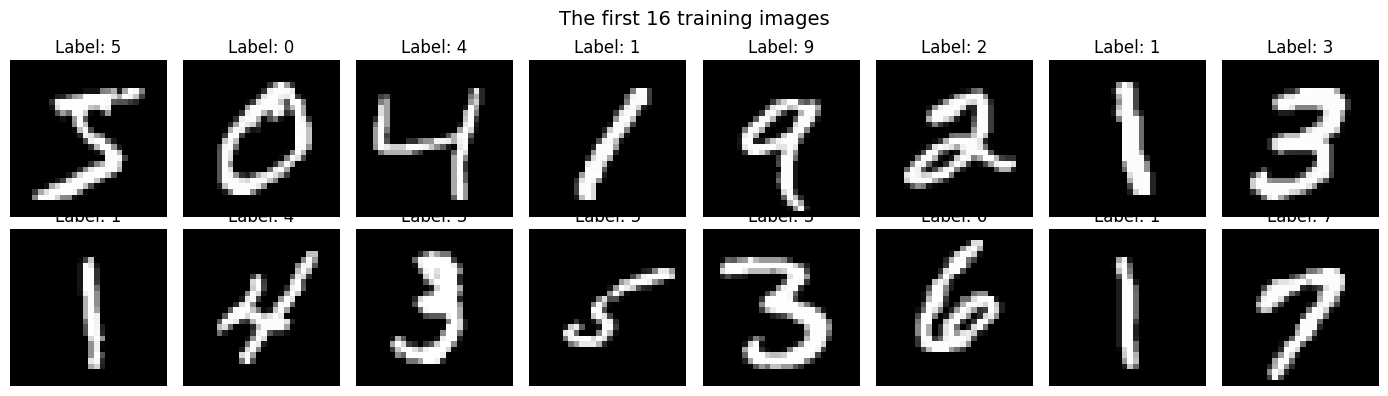

In [4]:
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(mnist_train.data[i], cmap="gray")
    ax.set_title(f"Label: {mnist_train.targets[i].item()}")
    ax.axis("off")
plt.suptitle("The first 16 training images", fontsize=14)
plt.tight_layout()
plt.show()

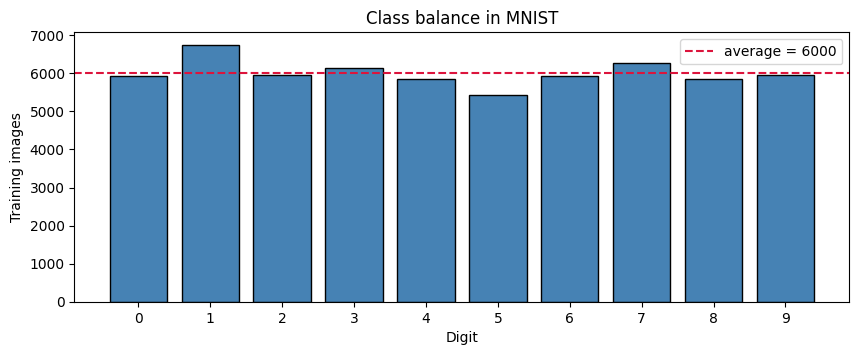

Always-guess-the-most-common-digit accuracy: 11.24%


In [5]:
counts = torch.bincount(mnist_train.targets)

plt.figure(figsize=(10, 3.5))
plt.bar(range(10), counts.numpy(), color="steelblue", edgecolor="black")
plt.axhline(counts.float().mean().item(), color="crimson", linestyle="--",
            label=f"average = {counts.float().mean().item():.0f}")
plt.xticks(range(10)); plt.xlabel("Digit"); plt.ylabel("Training images")
plt.title("Class balance in MNIST"); plt.legend(); plt.show()

print(f"Always-guess-the-most-common-digit accuracy: {counts.max().item() / len(mnist_train):.2%}")

In [6]:
# 🧩 FILL IN THE BLANKS

X_train = mnist_train.data.float().view(-1, 784) / 255
y_train = mnist_train.targets

X_test  = mnist_test.data.float().view(-1, 784) / 255
y_test  = mnist_test.targets

print("Before:", mnist_train.data.shape)
print("After: ", X_train.shape)
print("New pixel range:", X_train.min().item(), "to", X_train.max().item())
print("New dtype:      ", X_train.dtype)

Before: torch.Size([60000, 28, 28])
After:  torch.Size([60000, 784])
New pixel range: 0.0 to 1.0
New dtype:       torch.float32


✅ `[60000, 784]` • range `0.0 to 1.0` • dtype `float32`

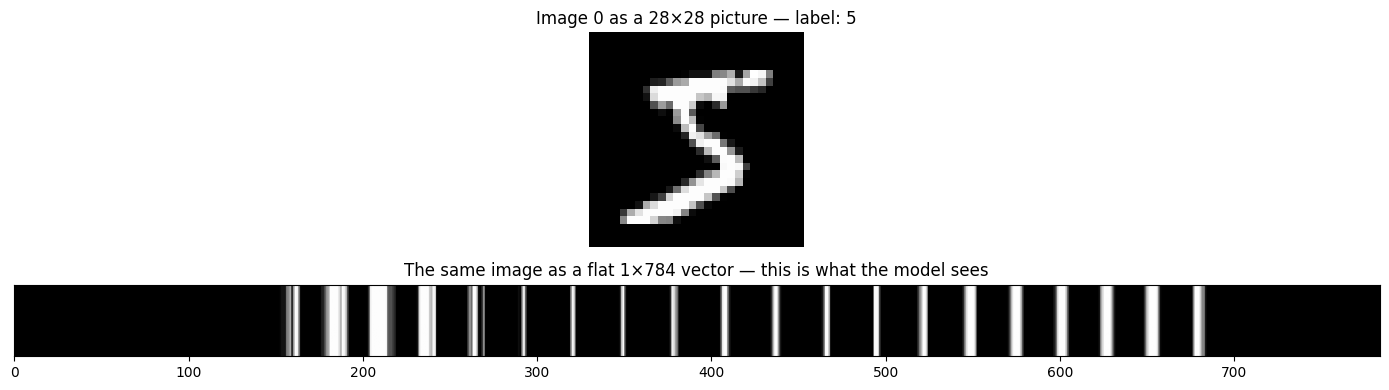

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 4), gridspec_kw={"height_ratios": [3, 1]})
axes[0].imshow(X_train[0].view(28, 28), cmap="gray")
axes[0].set_title(f"Image 0 as a 28×28 picture — label: {y_train[0].item()}")
axes[0].axis("off")
axes[1].imshow(X_train[0].view(1, 784), cmap="gray", aspect="auto")
axes[1].set_title("The same image as a flat 1×784 vector — this is what the model sees")
axes[1].set_yticks([])
plt.tight_layout(); plt.show()

In [8]:
# 🧩 FILL IN THE BLANKS

train_ds = TensorDataset(X_train, y_train)
test_ds  = TensorDataset(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=128, shuffle=False)

print("Training batches:", len(train_loader))
print("Test batches:    ", len(test_loader))

xb, yb = next(iter(train_loader))
print("\nOne batch of images:", xb.shape)
print("One batch of labels:", yb.shape)
print("Labels in this batch:", yb[:16].tolist())

Training batches: 469
Test batches:     79

One batch of images: torch.Size([128, 784])
One batch of labels: torch.Size([128])
Labels in this batch: [1, 2, 8, 5, 2, 6, 9, 9, 9, 4, 0, 3, 9, 9, 5, 6]


✅ 469 training batches • `xb` is `[128, 784]` • `yb` is `[128]`

In [9]:
# 🧩 784 pixels in, 10 digit-scores out

single_layer = nn.Linear(784,10)

print("Weight shape:", single_layer.weight.shape)
print("Bias shape:  ", single_layer.bias.shape)
print("Total parameters:", sum(p.numel() for p in single_layer.parameters()))

Weight shape: torch.Size([10, 784])
Bias shape:   torch.Size([10])
Total parameters: 7850


✅ weight `[10, 784]` • bias `[10]` • **7850** parameters

In [10]:
out = single_layer(xb)

print("Input shape: ", xb.shape)
print("Output shape:", out.shape)
print("\nRaw scores for image 0:\n", out[0])
print("\nModel's guess:", out[0].argmax().item(), " | Actual label:", yb[0].item())

Input shape:  torch.Size([128, 784])
Output shape: torch.Size([128, 10])

Raw scores for image 0:
 tensor([-0.1215, -0.3348,  0.2435,  0.2003, -0.2909, -0.0312,  0.1894,  0.1724,
         0.1156,  0.2130], grad_fn=<SelectBackward0>)

Model's guess: 2  | Actual label: 1


In [11]:
# 🧩 FILL IN THE BLANKS

model = nn.Sequential(
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

print(model)
print("\nTotal parameters:", sum(p.numel() for p in model.parameters()))
print("Output shape:", model(xb).shape)

Sequential(
  (0): Linear(in_features=784, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=10, bias=True)
)

Total parameters: 101770
Output shape: torch.Size([128, 10])


✅ **101,770** parameters • output `[128, 10]`

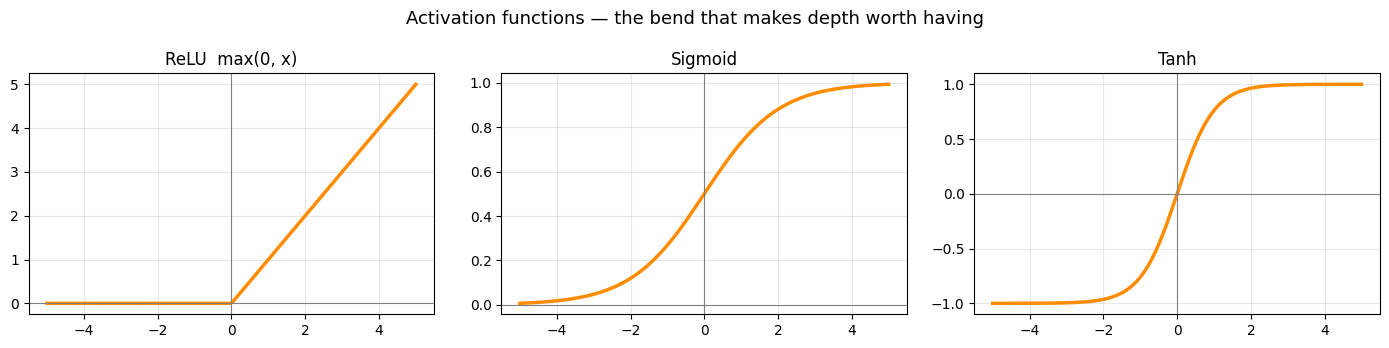

In [12]:
x = torch.linspace(-5, 5, 200)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, (name, fn) in zip(axes, [("ReLU  max(0, x)", torch.relu),
                                 ("Sigmoid", torch.sigmoid),
                                 ("Tanh", torch.tanh)]):
    ax.plot(x, fn(x), linewidth=2.5, color="darkorange")
    ax.axhline(0, color="gray", lw=0.8); ax.axvline(0, color="gray", lw=0.8)
    ax.set_title(name); ax.grid(alpha=0.3)
plt.suptitle("Activation functions — the bend that makes depth worth having", fontsize=13)
plt.tight_layout(); plt.show()

In [13]:
# 🧩 FILL IN THE BLANK

criterion = nn.CrossEntropyLoss()

preds = model(xb)
loss = criterion(preds, yb)

print("Loss on this batch:", loss.item())
print("Random guessing ≈ ln(10) =", np.log(10))

Loss on this batch: 2.3046391010284424
Random guessing ≈ ln(10) = 2.302585092994046


✅ close to `2.3`

In [14]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
torch.set_printoptions(precision=6, sci_mode=False)

# --- WEIGHTS BEFORE ---
weights_before = model[0].weight.clone()
print("Weights BEFORE (first 5 of layer 1, neuron 0):")
print(weights_before[0][:5])

Weights BEFORE (first 5 of layer 1, neuron 0):
tensor([ 0.023824,  0.012186, -0.025738, -0.012009,  0.022801],
       grad_fn=<SliceBackward0>)


In [16]:
# ============================================================
#   THE FIVE LINES THAT TRAIN A NEURAL NETWORK
# ============================================================

optimizer.zero_grad()         # 1. clear old gradients
preds = model(xb)             # 2. forward pass
loss = criterion(preds, yb)   # 3. how wrong are we
loss.backward()               # 4. compute gradients
optimizer.step()              # 5. update the weights

print("Loss for this step:", loss.item())

Loss for this step: 2.212728500366211


In [17]:
# --- WEIGHTS AFTER ---
weights_after = model[0].weight.clone()

print("BEFORE:", weights_before[0][:5])
print("AFTER: ", weights_after[0][:5])
print("MOVED: ", (weights_after - weights_before)[0][:5])
print("\nWeights that changed:", (weights_after != weights_before).sum().item(),
      "out of", weights_before.numel())

BEFORE: tensor([ 0.023824,  0.012186, -0.025738, -0.012009,  0.022801],
       grad_fn=<SliceBackward0>)
AFTER:  tensor([ 0.023824,  0.012186, -0.025738, -0.012009,  0.022801],
       grad_fn=<SliceBackward0>)
MOVED:  tensor([0., 0., 0., 0., 0.], grad_fn=<SliceBackward0>)

Weights that changed: 63219 out of 100352


In [18]:
new_loss = criterion(model(xb), yb)

print("Loss BEFORE the step:", loss.item())
print("Loss AFTER  the step:", new_loss.item())
print("Improvement:         ", loss.item() - new_loss.item())

Loss BEFORE the step: 2.212728500366211
Loss AFTER  the step: 2.1297788619995117
Improvement:          0.08294963836669922


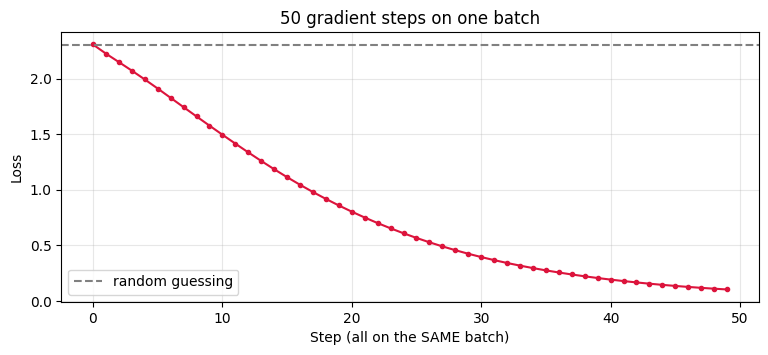

Loss went from 2.3063 → 0.1032


In [19]:
mini_model = nn.Sequential(nn.Linear(784, 128), nn.ReLU(), nn.Linear(128, 10))
mini_optim = torch.optim.Adam(mini_model.parameters(), lr=1e-3)   # 🔬 try 1e-1 and 1e-5

losses = []
for step in range(50):
    mini_optim.zero_grad()
    l = criterion(mini_model(xb), yb)
    l.backward()
    mini_optim.step()
    losses.append(l.item())

plt.figure(figsize=(9, 3.5))
plt.plot(losses, marker="o", markersize=3, color="crimson")
plt.axhline(np.log(10), color="gray", linestyle="--", label="random guessing")
plt.xlabel("Step (all on the SAME batch)"); plt.ylabel("Loss")
plt.title("50 gradient steps on one batch"); plt.legend(); plt.grid(alpha=0.3); plt.show()

print(f"Loss went from {losses[0]:.4f} → {losses[-1]:.4f}")

In [20]:
# 🧩 FILL IN THE FIVE LINES

model = nn.Sequential(nn.Linear(784, 128), nn.ReLU(), nn.Linear(128, 10)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

running_loss = 0.0
batch_losses = []

for i, (xb, yb) in enumerate(train_loader):
    xb, yb = xb.to(device), yb.to(device)

    optimizer.zero_grad()         # 1. clear old gradients
    preds = model(xb)             # 2. forward pass
    loss  = criterion(preds, yb)  # 3. how wrong are we
    loss.backward()               # 4. compute gradients
    optimizer.step()              # 5. update the weights

    running_loss += loss.item()
    batch_losses.append(loss.item())

    if i % 100 == 0:
        print(f"  batch {i:3d}/{len(train_loader)} | loss: {loss.item():.4f}")

print(f"\nAverage loss this epoch: {running_loss / len(train_loader):.4f}")

  batch   0/469 | loss: 2.3094
  batch 100/469 | loss: 0.4697
  batch 200/469 | loss: 0.3684
  batch 300/469 | loss: 0.3446
  batch 400/469 | loss: 0.1934

Average loss this epoch: 0.4147


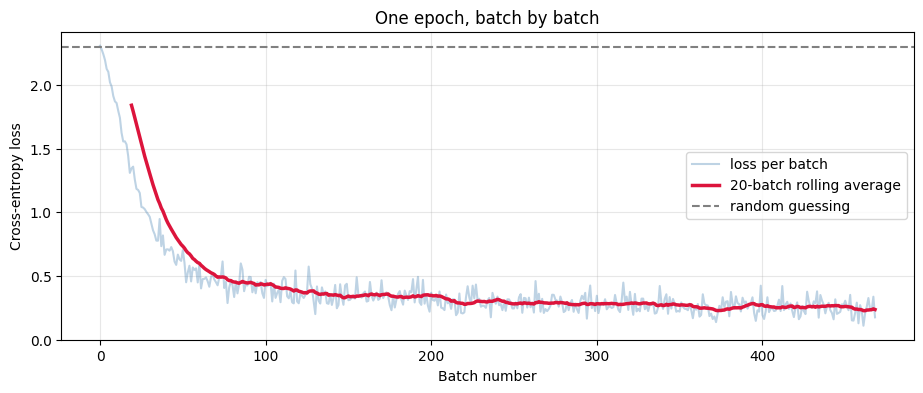

In [21]:
plt.figure(figsize=(11, 4))
plt.plot(batch_losses, alpha=0.35, color="steelblue", label="loss per batch")

window = 20
smooth = np.convolve(batch_losses, np.ones(window) / window, mode="valid")
plt.plot(range(window - 1, len(batch_losses)), smooth,
         color="crimson", linewidth=2.5, label=f"{window}-batch rolling average")

plt.axhline(np.log(10), color="gray", linestyle="--", label="random guessing")
plt.xlabel("Batch number"); plt.ylabel("Cross-entropy loss")
plt.title("One epoch, batch by batch"); plt.legend(); plt.grid(alpha=0.3); plt.show()

In [23]:
# 🧩 FILL IN THE BLANKS

model.eval()
correct, total = 0, 0

with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        preds = model(xb).argmax(dim=1)
        correct += (preds == yb).sum().item()
        total   += yb.size(0)

print(f"Test accuracy: {correct}/{total} = {correct/total:.4f}")
print("Baseline (always guess the most common digit): 0.1135")

Test accuracy: 9358/10000 = 0.9358
Baseline (always guess the most common digit): 0.1135


In [24]:
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb).argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
    return correct / total


def train_model(model, train_loader, val_loader, epochs=5, lr=1e-3):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_acc": []}
    print(f"Accuracy BEFORE training: {evaluate(model, val_loader):.4f}\n")

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()          # 1
            preds = model(xb)              # 2
            loss = criterion(preds, yb)    # 3
            loss.backward()                # 4
            optimizer.step()               # 5

            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)
        val_acc = evaluate(model, val_loader)
        history["train_loss"].append(train_loss)
        history["val_acc"].append(val_acc)
        print(f"Epoch {epoch+1:2d}/{epochs} | loss: {train_loss:.4f} | val acc: {val_acc:.4f}")

    print(f"\nAccuracy AFTER training: {evaluate(model, val_loader):.4f}")
    return model, history


def plot_history(history, title="Training curves"):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
    axes[0].plot(epochs, history["train_loss"], marker="o", color="crimson")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Training loss")
    axes[0].set_title("Loss — should go DOWN"); axes[0].grid(alpha=0.3)
    axes[1].plot(epochs, history["val_acc"], marker="o", color="seagreen")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Validation accuracy")
    axes[1].set_title("Accuracy — should go UP"); axes[1].grid(alpha=0.3)
    plt.suptitle(title, fontsize=13); plt.tight_layout(); plt.show()

print("✅ evaluate(), train_model(), plot_history() ready.")

✅ evaluate(), train_model(), plot_history() ready.


In [26]:
# 🧩 FILL IN THE BLANKS

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)


demo = MLP(input_dim=784, hidden_dim=128, output_dim=10)
print(demo)
print("\nParameters:", sum(p.numel() for p in demo.parameters()))
print("Output on a real batch:", demo(xb.cpu()).shape)

MLP(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=10, bias=True)
  )
)

Parameters: 101770
Output on a real batch: torch.Size([16, 10])


✅ **101,770** parameters • output `[128, 10]` — identical to the `Sequential` version

In [27]:
mnist_model = MLP(input_dim=784, hidden_dim=128, output_dim=10)
mnist_model, mnist_history = train_model(mnist_model, train_loader, test_loader, epochs=5)

Accuracy BEFORE training: 0.0845

Epoch  1/5 | loss: 0.4113 | val acc: 0.9331
Epoch  2/5 | loss: 0.1949 | val acc: 0.9521
Epoch  3/5 | loss: 0.1423 | val acc: 0.9619
Epoch  4/5 | loss: 0.1098 | val acc: 0.9669
Epoch  5/5 | loss: 0.0882 | val acc: 0.9719

Accuracy AFTER training: 0.9719


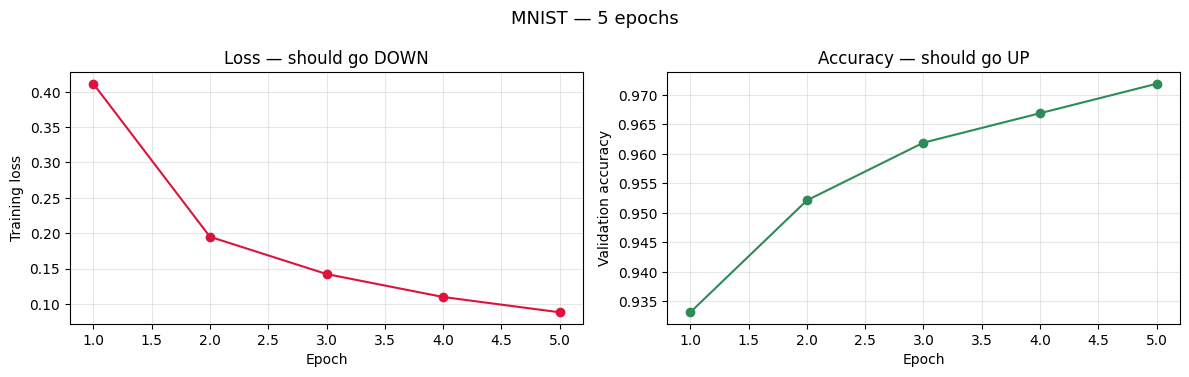

In [28]:
plot_history(mnist_history, "MNIST — 5 epochs")

✅ starts ~`0.10` (random) → ends ~`0.97–0.98`

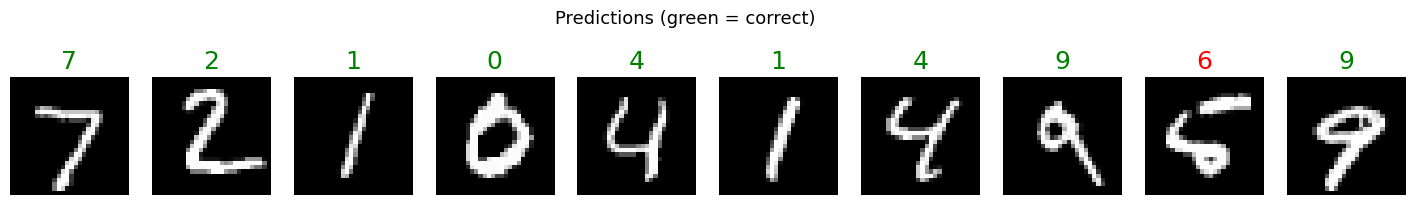

Predicted: [7, 2, 1, 0, 4, 1, 4, 9, 6, 9]
Actual:    [7, 2, 1, 0, 4, 1, 4, 9, 5, 9]


In [29]:
mnist_model.eval()
sample_x = X_test[:10].to(device)
sample_y = y_test[:10]

with torch.no_grad():
    preds = mnist_model(sample_x).argmax(dim=1).cpu()

fig, axes = plt.subplots(1, 10, figsize=(18, 2.6))
for i, ax in enumerate(axes):
    ax.imshow(sample_x[i].cpu().view(28, 28), cmap="gray")
    ok = preds[i].item() == sample_y[i].item()
    ax.set_title(f"{preds[i].item()}", color="green" if ok else "red", fontsize=18)
    ax.axis("off")
plt.suptitle("Predictions (green = correct)", fontsize=13); plt.show()

print("Predicted:", preds.tolist())
print("Actual:   ", sample_y.tolist())

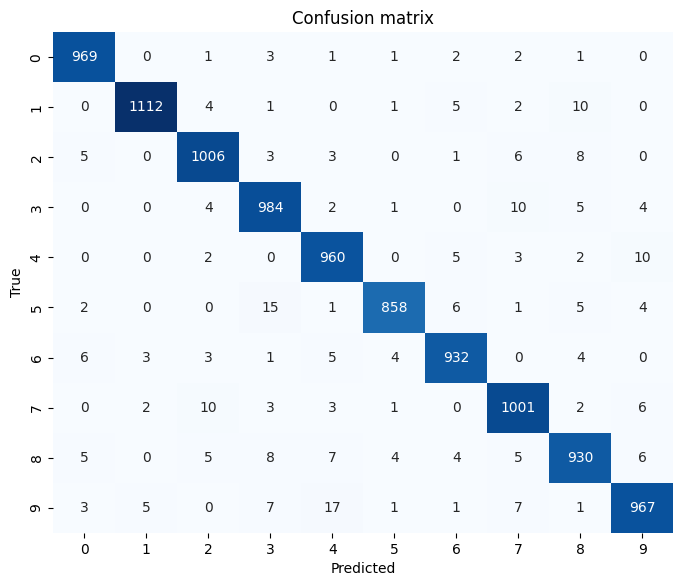

Most common mistake: a true 9 predicted as 4, 17 times.


In [33]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

all_preds, all_true = [], []
mnist_model.eval()
with torch.no_grad():
    for xb_, yb_ in test_loader:
        all_preds.append(mnist_model(xb_.to(device)).argmax(dim=1).cpu())
        all_true.append(yb_)

all_preds = torch.cat(all_preds).numpy()
all_true  = torch.cat(all_true).numpy()
cm = confusion_matrix(all_true, all_preds)

plt.figure(figsize=(8, 6.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Confusion matrix"); plt.show()

off = cm.copy(); np.fill_diagonal(off, 0)
i, j = np.unravel_index(off.argmax(), off.shape)
print(f"Most common mistake: a true {i} predicted as {j}, {off[i, j]} times.")

Accuracy BEFORE training: 0.1257

Epoch  1/3 | loss: 1.9212 | val acc: 0.8110
Epoch  2/3 | loss: 1.1778 | val acc: 0.8451
Epoch  3/3 | loss: 0.7849 | val acc: 0.8719

Accuracy AFTER training: 0.8719


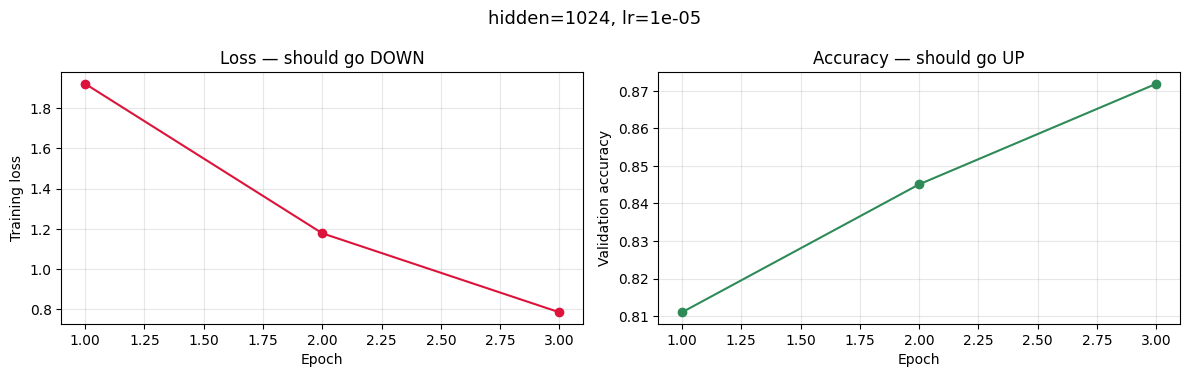

In [34]:
# 🔬 CHANGE THESE AND RE-RUN

HIDDEN_DIM = 1024     # try 8, 32, 512
LEARNING_RATE = 1e-5  # try 1e-1, 1e-2, 1e-4, 1e-5
EPOCHS = 3

torch.manual_seed(42)
exp_model = MLP(input_dim=784, hidden_dim=HIDDEN_DIM, output_dim=10)
exp_model, exp_history = train_model(exp_model, train_loader, test_loader,
                                     epochs=EPOCHS, lr=LEARNING_RATE)
plot_history(exp_history, f"hidden={HIDDEN_DIM}, lr={LEARNING_RATE}")

In [35]:
torch.manual_seed(42)
no_relu = nn.Sequential(nn.Linear(784, 128), nn.Linear(128, 10))   # 👈 no ReLU
no_relu, hist_no_relu = train_model(no_relu, train_loader, test_loader, epochs=3)

torch.manual_seed(42)
one_layer = nn.Sequential(nn.Linear(784, 10))
one_layer, hist_one = train_model(one_layer, train_loader, test_loader, epochs=3)

print("\n" + "=" * 55)
print(f"Two Linear layers, NO ReLU : {hist_no_relu['val_acc'][-1]:.4f}")
print(f"One Linear layer           : {hist_one['val_acc'][-1]:.4f}")
print(f"Two Linear layers + ReLU   : {exp_history['val_acc'][-1]:.4f}")
print("=" * 55)

Accuracy BEFORE training: 0.1066

Epoch  1/3 | loss: 0.4192 | val acc: 0.9210
Epoch  2/3 | loss: 0.2907 | val acc: 0.9250
Epoch  3/3 | loss: 0.2768 | val acc: 0.9251

Accuracy AFTER training: 0.9251
Accuracy BEFORE training: 0.1347

Epoch  1/3 | loss: 0.6612 | val acc: 0.9011
Epoch  2/3 | loss: 0.3595 | val acc: 0.9142
Epoch  3/3 | loss: 0.3179 | val acc: 0.9184

Accuracy AFTER training: 0.9184

Two Linear layers, NO ReLU : 0.9251
One Linear layer           : 0.9184
Two Linear layers + ReLU   : 0.8719
